# RQ2 — What's the Trend? (Quarterly Median Download/Upload/Latency, 2023Q1–2025Q4)

RQ1 (`rq1_thresholds_ookla.ipynb`, `rq1_thresholds_ndt7.ipynb`) asked a snapshot question — is
Thai internet good or bad against app-requirement thresholds. RQ2 asks the time dimension: is it
**getting better, worse, or flat** over the 12 quarters we have data for (2023-Q1 to 2025-Q4)?

Method follows the **Fig. 7 template from Lübben & Misfeld (2022)** — median line with 25th/75th
percentile band per period, per segment — adapted from their monthly TCP-protocol view to our
quarterly Ookla-vs-NDT7, fixed-vs-mobile view.

Four segments, Thailand only:
| Segment | Export file |
|---|---|
| Ookla fixed | `ookla_province_quarterly.csv` |
| Ookla mobile | `ookla_mobile_province_quarterly.csv` |
| NDT7 fixed (reliable) | `ndt7_broadband_thailand_reliable_province_quarterly.csv` |
| NDT7 mobile (reliable) | `ndt7_mobile_thailand_reliable_province_quarterly.csv` |

**Scope note (added, matching RQ1's cross-country lens):** the four-segment analysis above is
Thailand-only by design — it's the deep dive (NDT7 cross-validation, Bangkok-metro drilldown) that
only Thailand (and, for NDT7, Vietnam) has the data to support. A new section at the end,
**"SEA context — Thailand's download growth vs 7 neighbors,"** extends RQ1's cross-country
snapshot to the time dimension: Ookla fixed, download only, all 8 countries, same scope discipline
RQ1 used (mobile/upload/latency cross-country trend deferred as out of scope for this pass).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXPORTS = Path('../../data/exports')

SEGMENTS = {
    'Ookla fixed':  'ookla_province_quarterly.csv',
    'Ookla mobile': 'ookla_mobile_province_quarterly.csv',
    'NDT7 fixed':   'ndt7_broadband_thailand_reliable_province_quarterly.csv',
    'NDT7 mobile':  'ndt7_mobile_thailand_reliable_province_quarterly.csv',
}
COLORS = {
    'Ookla fixed':  '#0072B2',
    'Ookla mobile': '#56B4E9',
    'NDT7 fixed':   '#D55E00',
    'NDT7 mobile':  '#E69F00',
}
QUARTERS = [f'{y}-Q{q}' for y in (2023, 2024, 2025) for q in (1, 2, 3, 4)]

frames = []
for seg, fname in SEGMENTS.items():
    d = pd.read_csv(EXPORTS / fname)
    d['segment'] = seg
    frames.append(d)
all_df = pd.concat(frames, ignore_index=True)
all_df['quarter'] = pd.Categorical(all_df['quarter'], categories=QUARTERS, ordered=True)
all_df.shape

(2369, 16)

### Coverage caveat — sample thins unevenly across segments and time

**Ookla fixed is missing 2025-Q3 entirely** (export gap, not a real-world drop to zero — treat as
a missing point, don't connect the line through it as if measured).

**NDT7 mobile collapses after 2024-Q1**: province coverage per quarter goes
17 → 12 → 12 → 15 → 9 → **2 → 2 → 3 → 3 → 2 → 2 → 2** (2023-Q1 through 2025-Q4). From 2024-Q2
onward the "national" NDT7 mobile median is really just Bangkok Metropolis + 1-2 other provinces
that happened to clear the `total_tests>=100 & n_tiles>=5` reliability bar that quarter — not a
representative national sample. Read the NDT7 mobile line past 2024-Q1 as **indicative, not a
population estimate**.

In [2]:
coverage = (
    all_df.groupby(['segment', 'quarter'], observed=True)
    .agg(n_provinces=('province', 'nunique'), n_tests=('total_tests', 'sum'))
    .reset_index()
)
coverage.pivot(index='quarter', columns='segment', values='n_provinces')

segment,NDT7 fixed,NDT7 mobile,Ookla fixed,Ookla mobile
quarter,,,,
2023-Q1,67.0,17.0,77.0,77.0
2023-Q2,68.0,12.0,77.0,77.0
2023-Q3,65.0,12.0,77.0,77.0
2023-Q4,66.0,15.0,77.0,77.0
2024-Q1,63.0,9.0,77.0,77.0
2024-Q2,36.0,2.0,77.0,77.0
2024-Q3,24.0,2.0,77.0,77.0
2024-Q4,29.0,3.0,77.0,77.0
2025-Q1,27.0,3.0,77.0,77.0


### Trend method

Per segment, per quarter: **median**, **25th percentile**, **75th percentile** of
`avg_d_mbps` / `avg_u_mbps` / `avg_lat_ms_wt` across that quarter's province-level rows
(unweighted across provinces — same convention as Fig. 7, which plots percentiles across
measurement units, not weighted by volume). Province-quarters are the unit here, same as RQ1.

In [3]:
def quarterly_stats(df, col):
    g = df.groupby(['segment', 'quarter'], observed=True)[col]
    out = g.agg(median='median', p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75)).reset_index()
    return out

def plot_trend(ax, stats, ylabel):
    for seg in SEGMENTS:
        s = stats[stats['segment'] == seg].set_index('quarter').reindex(QUARTERS)
        x = np.arange(len(QUARTERS))
        ax.plot(x, s['median'], marker='o', markersize=3, label=seg, color=COLORS[seg], linewidth=1.6)
        ax.fill_between(x, s['p25'], s['p75'], color=COLORS[seg], alpha=0.12)
    ax.set_xticks(np.arange(len(QUARTERS)))
    ax.set_xticklabels(QUARTERS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.25)

### Download trend

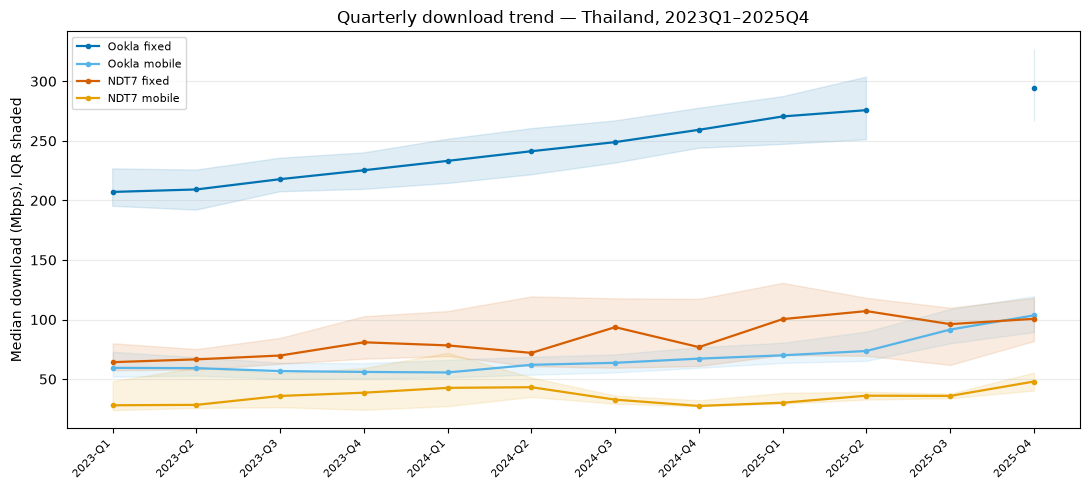

In [4]:
d_stats = quarterly_stats(all_df, 'avg_d_mbps')
fig, ax = plt.subplots(figsize=(11, 5))
plot_trend(ax, d_stats, 'Median download (Mbps), IQR shaded')
ax.legend(fontsize=8)
ax.set_title('Quarterly download trend — Thailand, 2023Q1–2025Q4')
plt.tight_layout()
plt.show()

**Download findings.** All four segments trend up over the 3 years — no segment is flat or
declining:

- **Ookla fixed**: steady, near-linear growth, 207 → 294 Mbps (+42%). The best-resourced,
  least-noisy series here (largest `n_provinces`/`n_tests` of the four).
- **NDT7 fixed**: noisier but the same direction, 64 → ~100 Mbps (+56% by 2025-Q4, peak 107 in
  2025-Q2). Tracks Ookla fixed's *direction* even though the absolute level is ~3x lower (same gap
  RQ1 attributes to NDT7's single-TCP-stream, `lower-bound` methodology vs Ookla's multi-connection
  test).
- **Ookla mobile**: flat through 2023 (~55-60 Mbps), then a real inflection from 2024-Q2 onward,
  reaching 91-104 Mbps by 2025-Q3/Q4 — consistent with a 5G-rollout story rather than measurement
  noise (Ookla mobile has the 2nd-largest sample of the four segments).
- **NDT7 mobile**: bounces 27-48 Mbps with no clean trend — this is the thin-sample segment (2-3
  provinces per quarter after 2024-Q1, see coverage caveat above); don't read a trend into this
  line, it's dominated by which 1-3 provinces happened to qualify that quarter.

**Bottom line: fixed broadband capacity growth is real and monotonic on both platforms; mobile
shows a genuine 2024-2025 speed jump on Ookla, but NDT7 mobile's sample is too thin post-2024-Q1
to confirm or deny the same jump independently.**

### Upload trend

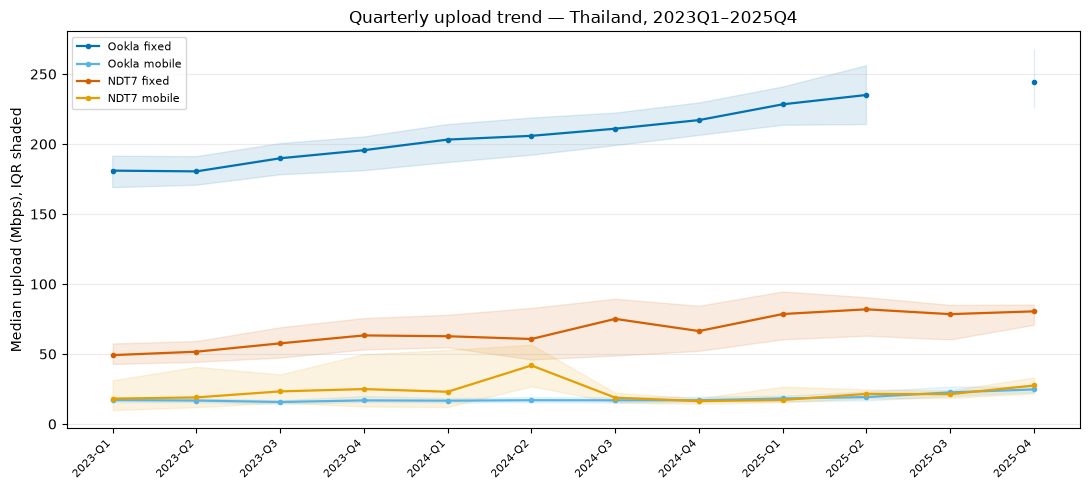

In [5]:
u_stats = quarterly_stats(all_df, 'avg_u_mbps')
fig, ax = plt.subplots(figsize=(11, 5))
plot_trend(ax, u_stats, 'Median upload (Mbps), IQR shaded')
ax.legend(fontsize=8)
ax.set_title('Quarterly upload trend — Thailand, 2023Q1–2025Q4')
plt.tight_layout()
plt.show()

**Upload findings.** Same shape as download, smaller magnitude — Ookla fixed 181 → 245 Mbps
(+35%), NDT7 fixed 49 → 81 Mbps (+63%), both monotonically up. Ookla mobile is flat at ~17 Mbps
through all of 2023-2024, then rises to 23-25 Mbps in 2025 — a smaller but same-direction echo of
the download inflection, supporting the 5G-rollout read rather than a download-only artifact.
NDT7 mobile upload is noisy with no trend (same thin-sample caveat as download).

### Latency trend

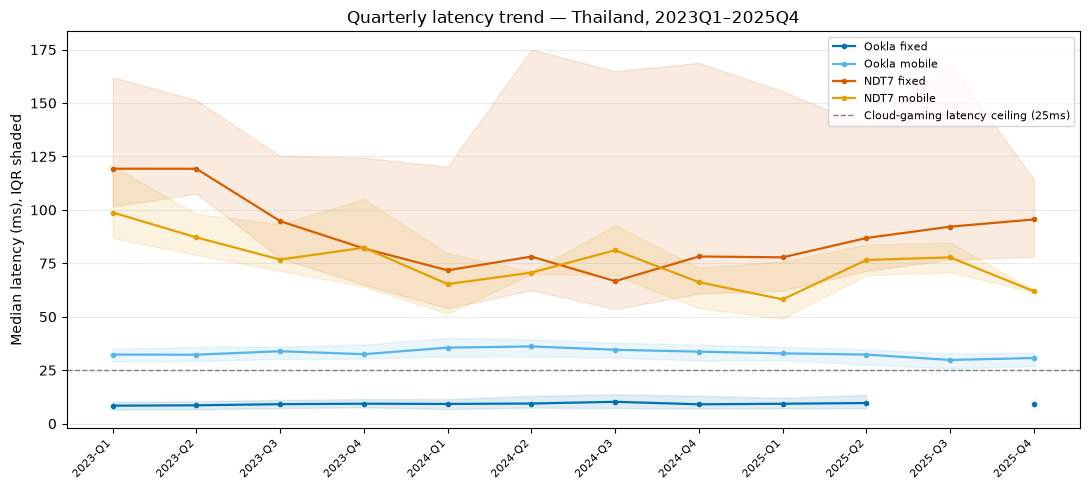

In [6]:
l_stats = quarterly_stats(all_df, 'avg_lat_ms_wt')
fig, ax = plt.subplots(figsize=(11, 5))
plot_trend(ax, l_stats, 'Median latency (ms), IQR shaded')
ax.axhline(25, color='gray', linestyle='--', linewidth=1, label='Cloud-gaming latency ceiling (25ms)')
ax.legend(fontsize=8)
ax.set_title('Quarterly latency trend — Thailand, 2023Q1–2025Q4')
plt.tight_layout()
plt.show()

**Latency findings.** The chart makes RQ1's "0% everywhere" cloud-gaming finding concrete as a
**time-invariant structural gap**, not a snapshot artifact:

- **Ookla fixed** sits at 8-10ms the entire 3 years — already far below the 25ms ceiling, flat (no
  trend either direction, nothing to improve).
- **Ookla mobile** holds at 30-36ms, hovering just above the ceiling with at most a marginal dip in
  late 2025 (33 → 30 → 29 → 31ms) — too small relative to the IQR band to call a real trend.
- **NDT7 fixed and mobile both stay in the 60-120ms range for all 12 quarters**, never once
  approaching the 25ms line — the gap to Ookla is 6-12x and does not close over time. This matches
  RQ1's read: NDT7's RTT is measured to M-Lab's own server infrastructure (Google Cloud PoPs), not
  to a local/regional ISP test server the way Ookla's is, so the latency floor is a **routing/server-
  placement artifact of the M-Lab platform**, not a Thai last-mile quality signal — and 3 years of
  data confirm it's persistent, not transient.

**This is the strongest argument in the whole analysis for why NDT7 latency numbers should not be
read as real-time-application latency (voice/gaming) without the platform-artifact caveat — it's
not a one-quarter fluke.**

### RQ1 revisited over time — Bangkok metro mobile degradation, improving or not?

RQ1 found the Bangkok metro cluster (Bangkok Metropolis, Nonthaburi, Samut Prakan, Pathum Thani)
underperforms on NDT7 mobile UHD pass rate (55-67%) while secondary cities sit at 100%. Given the
coverage collapse noted above, this can only be checked where the cluster has data — mostly
2023-Q1 through 2024-Q1.

In [7]:
BKK_METRO = {'Bangkok Metropolis', 'Nonthaburi', 'Samut Prakan', 'Pathum Thani'}
mobile = all_df[all_df['segment'] == 'NDT7 mobile'].copy()
mobile['group'] = np.where(mobile['province'].isin(BKK_METRO), 'Bangkok metro', 'Rest of Thailand')
mobile['uhd_pass'] = mobile['avg_d_mbps'] >= 25

def weighted_pass_rate(d):
    w = d['total_tests']
    return np.average(d['uhd_pass'], weights=w) * 100

trend = (
    mobile.groupby(['group', 'quarter'], observed=True)
    .apply(lambda d: pd.Series({'uhd_pass_pct': weighted_pass_rate(d), 'n_provinces': d['province'].nunique(), 'n_tests': d['total_tests'].sum()}), include_groups=False)
    .reset_index()
)
trend.pivot(index='quarter', columns='group', values='uhd_pass_pct')

group,Bangkok metro,Rest of Thailand
quarter,,
2023-Q1,0.220959,65.436584
2023-Q2,7.295675,91.746251
2023-Q3,2.031952,100.000000
2023-Q4,3.906419,97.517659
2024-Q1,100.000000,98.006122
2024-Q2,100.000000,NaN
2024-Q3,100.000000,100.000000
2024-Q4,100.000000,NaN
2025-Q1,100.000000,100.000000


**Bangkok-metro-vs-rest findings — this is the headline result of RQ2.** RQ1's pooled 2023-2025
average (55-67% UHD pass rate for Bangkok metro) hid a sharp step change:

| Period | Bangkok metro | Rest of Thailand |
|---|---|---|
| 2023-Q1 | **0%** | 65% |
| 2023-Q2 | 7% | 92% |
| 2023-Q3 | 2% | 100% |
| 2023-Q4 | 4% | 98% |
| 2024-Q1 onward | **100%** (every quarter) | 98-100% |

Bangkok metro was **effectively failing the UHD threshold entirely through all of 2023** (0-7%,
on a solid 4-province sample each quarter) while the rest of the country was already mostly
passing (65% and climbing to 100% by Q3). Then **at 2024-Q1, Bangkok metro jumps to 100% and stays
there every quarter through 2025-Q4** — a clean, sudden recovery rather than a gradual close.

Caveat: from 2024-Q3 onward both groups run on 1-3 provinces per quarter (coverage-collapse
caveat above applies), so the *sustained* 100% since then is indicative, not statistically tight —
but the **2023 failure → 2024-Q1 recovery transition itself** rests on a decent sample (4 vs 8-13
provinces) and is the reliable part of this finding.

**RQ1's "Bangkok metro underperforms" framing is therefore a 2023 story that had already resolved
by the time of writing (mid-2025) — not an ongoing problem.** Worth flagging as a limitation on
RQ1's headline claim, and worth a footnote on what changed at the 2023/2024 boundary (infra
upgrade? MNO capacity add? seasonal effect from the 2023 sample composition?) if that context is
findable elsewhere in the sourced literature.

### SEA context — Thailand's download growth vs 7 neighbors (Ookla fixed)

RQ1 compared Thailand against 7 SEA neighbors as a **snapshot** (pooled 2023-2025 average
threshold pass rates). This extends that same cross-country lens to the **time dimension**: does
Thailand's +42% download growth (established above) look typical, ahead, or behind its neighbors'
own growth over the same 12 quarters?

**Scope**: Ookla fixed, download only, matching RQ1's own scope discipline (mobile/upload/latency
cross-country trend deferred — not core to answering "is Thailand's growth normal for the
region"). NDT7 is out of scope here regardless (only Thailand + Vietnam have NDT7 data).

In [8]:
COUNTRY_FILES = {
    'Thailand':    'ookla_province_quarterly.csv',
    'Vietnam':     'ookla_vietnam_province_quarterly.csv',
    'Philippines': 'ookla_philippines_province_quarterly.csv',
    'Singapore':   'ookla_singapore_province_quarterly.csv',
    'Cambodia':    'ookla_cambodia_province_quarterly.csv',
    'Laos':        'ookla_laos_province_quarterly.csv',
    'Malaysia':    'ookla_malaysia_province_quarterly.csv',
    'Myanmar':     'ookla_myanmar_province_quarterly.csv',
}

country_frames = []
for country, fname in COUNTRY_FILES.items():
    d = pd.read_csv(EXPORTS / fname)
    d['country'] = country
    country_frames.append(d)
sea_df = pd.concat(country_frames, ignore_index=True)
sea_df['quarter'] = pd.Categorical(sea_df['quarter'], categories=QUARTERS, ordered=True)

# same 2025-Q3 export gap affects all 8 countries identically -- not a Thailand-specific artifact
sea_df.groupby('country', observed=True)['quarter'].apply(lambda s: sorted(set(QUARTERS) - set(s)))

country
Cambodia       [2025-Q3]
Laos           [2025-Q3]
Malaysia       [2025-Q3]
Myanmar        [2025-Q3]
Philippines    [2025-Q3]
Singapore      [2025-Q3]
Thailand       [2025-Q3]
Vietnam        [2025-Q3]
Name: quarter, dtype: object

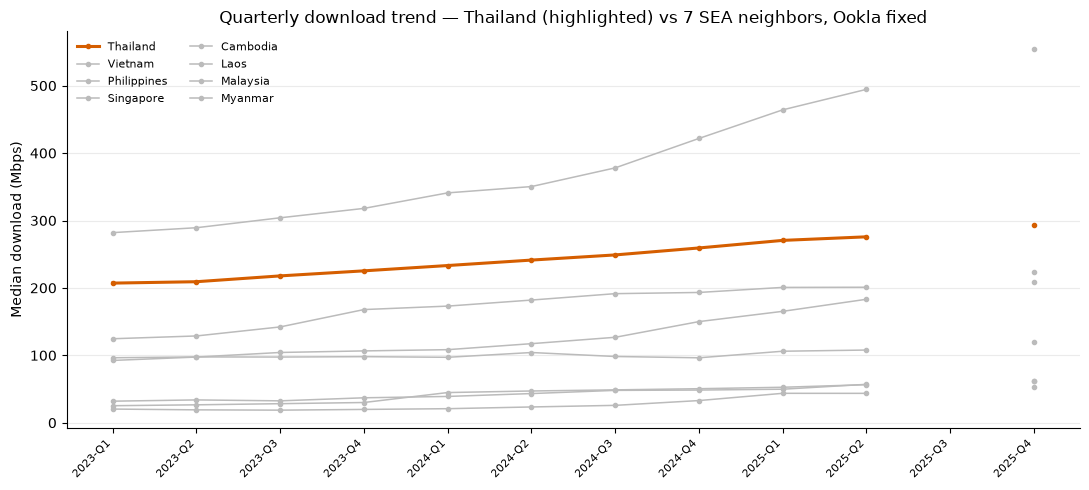

quarter,2023-Q1,2025-Q4,pct_growth
country,,,
Myanmar,20.3,53.6,163.8
Cambodia,25.3,61.7,144.1
Vietnam,92.4,209.2,126.4
Singapore,282.0,553.8,96.4
Laos,32.0,62.2,94.4
Malaysia,124.6,223.6,79.5
Thailand,207.1,294.0,42.0
Philippines,96.4,119.1,23.6


In [9]:
d_by_country = (
    sea_df.groupby(['country', 'quarter'], observed=True)['avg_d_mbps']
    .median().reset_index(name='median_d_mbps')
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(QUARTERS))
for country in COUNTRY_FILES:
    s = d_by_country[d_by_country['country'] == country].set_index('quarter').reindex(QUARTERS)
    is_th = country == 'Thailand'
    ax.plot(x, s['median_d_mbps'], marker='o', markersize=3, label=country,
            color='#D55E00' if is_th else '#BBBBBB',
            linewidth=2.2 if is_th else 1.1, zorder=3 if is_th else 2)
ax.set_xticks(x)
ax.set_xticklabels(QUARTERS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Median download (Mbps)')
ax.set_title('Quarterly download trend — Thailand (highlighted) vs 7 SEA neighbors, Ookla fixed')
ax.legend(fontsize=8, loc='upper left', ncol=2, frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

growth = (
    d_by_country[d_by_country['quarter'].isin(['2023-Q1', '2025-Q4'])]
    .pivot(index='country', columns='quarter', values='median_d_mbps')
    .assign(pct_growth=lambda d: (d['2025-Q4'] / d['2023-Q1'] - 1) * 100)
    .sort_values('pct_growth', ascending=False)
    .round(1)
)
growth

**SEA growth-context findings.** Thailand's +42.0% download growth (2023-Q1 → 2025-Q4) is the
**2nd-slowest of the 8 countries** — only the Philippines (+23.6%) grows slower:

| Country | 2023-Q1 | 2025-Q4 | % growth |
|---|---|---|---|
| Myanmar | 20.3 | 53.6 | +163.8% |
| Cambodia | 25.3 | 61.7 | +144.1% |
| Vietnam | 92.4 | 209.2 | +126.4% |
| Singapore | 282.0 | 553.8 | +96.4% |
| Laos | 32.0 | 62.2 | +94.4% |
| Malaysia | 124.6 | 223.6 | +79.5% |
| **Thailand** | **207.1** | **294.0** | **+42.0%** |
| Philippines | 96.4 | 119.1 | +23.6% |

This is **not** a sign Thailand is falling behind — it's the flip side of RQ1's finding that
Thailand already clears every speed threshold in this dataset with no headroom to gain from.
The four fastest-growing countries (Myanmar, Cambodia, Vietnam, Laos) are all growing off a much
lower 2023 base (20-92 Mbps) — classic catch-up growth. Singapore, the only country starting
*above* Thailand (282 Mbps in 2023-Q1), still posts +96.4%, more than double Thailand's rate,
which tempers the "Thailand is just plateauing at a high base" read somewhat — Singapore shows a
high base doesn't mechanically cap growth. Malaysia (+79.5%, base 125 Mbps) growing nearly 2x
faster than Thailand from a lower base is the one comparison that doesn't fit the pure
base-effect story and is worth a specific look in the Discussion section (ISP/infrastructure
investment cycle, not just diminishing-returns economics).

**Bottom line: Thailand's absolute download level stays 2nd-highest of the 8 (behind only
Singapore) throughout the entire period — the slower % growth reflects a high starting point,
not stagnation or decline.**

## Key Findings (RQ2)

- **Download**: monotonic growth on both fixed platforms (Ookla +42%, NDT7 +56% over 3 years) and
  on Ookla mobile (flat through 2023, +60-80% inflection from 2024-Q2). NDT7 mobile too thin
  post-2024-Q1 to confirm independently.
- **Upload**: same shape as download, smaller magnitude — real growth, not noise, on every segment
  except NDT7 mobile (thin-sample).
- **Latency**: Ookla stays flat and well under the 25ms cloud-gaming ceiling the entire period;
  NDT7 (fixed and mobile) sits at 60-120ms for all 12 quarters with **no convergence toward 25ms** —
  confirms RQ1's latency floor is a persistent M-Lab server-placement artifact, not a transient or
  improving last-mile issue.
- **Bangkok metro mobile (RQ1 follow-up)**: the underperformance RQ1 found (55-67% pooled) was
  driven entirely by 2023 (0-7% UHD pass rate) — Bangkok metro jumped to 100% at 2024-Q1 and has
  held there every quarter since. **The RQ1 finding is a resolved 2023 problem, not an ongoing one**
  — this is the single most important qualifier to add to the RQ1 write-up.
- **Overall RQ2 answer: getting better, on every metric that has a usable sample.** No segment
  shows a worsening trend anywhere in the 12 quarters. The main open question is not direction but
  whether NDT7 mobile's sample will recover enough post-2024 to say anything with confidence at
  province level again.
- **SEA growth context (new)**: Thailand's +42.0% download growth is 2nd-slowest of 8 SEA
  countries, but only because it starts 2nd-highest (207 Mbps, behind only Singapore) — absolute
  level stays 2nd of 8 throughout. The 4 fastest-growing countries (Myanmar, Cambodia, Vietnam,
  Laos) are catching up from a much lower base; Malaysia's faster growth from a lower base than
  Thailand's is the one exception worth a Discussion-section look.